<a href="https://colab.research.google.com/github/jorigo/Reto_2_TelecomX_P2/blob/main/TelecomX_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 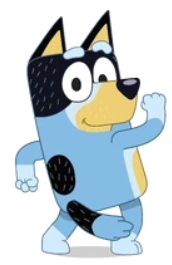**PREPARACION DE LOS DATOS**

In [1]:
import pandas as pd

file_path = "/content/drive/MyDrive/Colab Notebooks/Archivos_Pandas_DataBase/TelecomX_Datos_Procesados.json"
df = pd.read_json(file_path)

print("Archivo JSON cargado exitosamente en un DataFrame.")
print(df.head())

Archivo JSON cargado exitosamente en un DataFrame.
   ID_Cliente  Abandono  Genero  Ciudadano_Senior  Pareja  Dependientes  \
0  0002-ORFBO         0       0                 0       1             1   
1  0003-MKNFE         0       1                 0       0             0   
2  0004-TLHLJ         1       1                 0       0             0   
3  0011-IGKFF         1       1                 1       1             0   
4  0013-EXCHZ         1       0                 1       1             0   

   Antiguedad_Meses  Servicio_Telefonico  Multiples_Lineas Servicio_Internet  \
0                 9                    1                 0               DSL   
1                 9                    1                 1               DSL   
2                 4                    1                 0       Fiber optic   
3                13                    1                 0       Fiber optic   
4                 3                    1                 0       Fiber optic   

   ...  Proteccio

##**ELIMINACION DE COLUNAS NO RELEVANTES**

In [ ]:
df = df.drop('ID_Cliente', axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Abandono                7267 non-null   int64  
 1   Genero                  7267 non-null   int64  
 2   Ciudadano_Senior        7267 non-null   int64  
 3   Pareja                  7267 non-null   int64  
 4   Dependientes            7267 non-null   int64  
 5   Antiguedad_Meses        7267 non-null   int64  
 6   Servicio_Telefonico     7267 non-null   int64  
 7   Multiples_Lineas        7267 non-null   int64  
 8   Servicio_Internet       7267 non-null   object 
 9   Seguridad_Online        7267 non-null   int64  
 10  Copia_Seguridad_Online  7267 non-null   int64  
 11  Proteccion_Dispositivo  7267 non-null   int64  
 12  Soporte_Tecnico         7267 non-null   int64  
 13  Television_Streaming    7267 non-null   int64  
 14  Peliculas_Streaming     7267 non-null   

##**ENCODING**

In [5]:
# Seleccionar las columnas categóricas
categorical_cols = ['Servicio_Internet', 'Contrato', 'Metodo_Pago']


df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame con variables categóricas codificadas:")
print(df_encoded.head())
print("\nInformación del DataFrame después de la codificación:")
df_encoded.info()

DataFrame con variables categóricas codificadas:
   Abandono  Genero  Ciudadano_Senior  Pareja  Dependientes  Antiguedad_Meses  \
0         0       0                 0       1             1                 9   
1         0       1                 0       0             0                 9   
2         1       1                 0       0             0                 4   
3         1       1                 1       1             0                13   
4         1       0                 1       1             0                 3   

   Servicio_Telefonico  Multiples_Lineas  Seguridad_Online  \
0                    1                 0                 0   
1                    1                 1                 0   
2                    1                 0                 0   
3                    1                 0                 0   
4                    1                 0                 0   

   Copia_Seguridad_Online  ...  Cargos_Mensuales  Cargos_Totales  \
0                      

In [6]:
df_encoded

,Abandono,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,...,Cargos_Mensuales,Cargos_Totales,Cargos_Diarios,Servicio_Internet_Fiber optic,Servicio_Internet_No,Contrato_one year,Contrato_two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check
0,0,0,0,1,1,9,1,0,0,1,...,65.60,593.30,2.186667,False,False,True,False,False,False,True
1,0,1,0,0,0,9,1,1,0,0,...,59.90,542.40,1.996667,False,False,False,False,False,False,True
2,1,1,0,0,0,4,1,0,0,0,...,73.90,280.85,2.463333,True,False,False,False,False,True,False
3,1,1,1,1,0,13,1,0,0,1,...,98.00,1237.85,3.266667,True,False,False,False,False,True,False
4,1,0,1,1,0,3,1,0,0,0,...,83.90,267.40,2.796667,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,0,0,0,0,13,1,0,1,0,...,55.15,742.90,1.838333,False,False,True,False,False,False,True
7263,1,1,0,1,0,22,1,1,0,0,...,85.10,1873.70,2.836667,True,False,False,False,False,True,False
7264,0,1,0,0,0,2,1,0,0,1,...,50.30,92.75,1.676667,False,False,False,False,False,False,True
7265,0,1,0,1,1,67,1,0,1,0,...,67.85,4627.65,2.261667,False,False,False,True,False,False,True


##**Verificación de la Proporción de Cancelación (Churn)**

In [7]:
churn_counts = df_encoded['Abandono'].value_counts()
churn_proportions = df_encoded['Abandono'].value_counts(normalize=True) * 100

print("Conteo de clientes por estado de abandono:")
print(churn_counts)
print("\nProporción de clientes por estado de abandono (%):")
print(churn_proportions)

# Evaluar el desbalance
if churn_proportions[0] > 70 and churn_proportions[1] < 30:
    print("\nExiste un desbalance significativo entre las clases. La mayoría de los clientes no han abandonado el servicio.")
elif churn_proportions[1] > 70 and churn_proportions[0] < 30:
    print("\nExiste un desbalance significativo entre las clases. La mayoría de los clientes han abandonado el servicio.")
else:
    print("\nLas clases están relativamente balanceadas.")

Conteo de clientes por estado de abandono:
Abandono
0    5398
1    1869
Name: count, dtype: int64

Proporción de clientes por estado de abandono (%):
Abandono
0    74.280996
1    25.719004
Name: proportion, dtype: float64

Existe un desbalance significativo entre las clases. La mayoría de los clientes no han abandonado el servicio.


##**Balanceo de Clases**

In [8]:
# Instalar imbalanced-learn si no está instalado
!pip install imbalanced-learn

In [9]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import pandas as pd

# Separar características (X) y la variable objetivo (y)
X = df_encoded.drop('Abandono', axis=1)
y = df_encoded['Abandono']

print(f"Distribución de clases original: {Counter(y)}")

# Aplico SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Distribución de clases después de SMOTE: {Counter(y_resampled)}")

# Creo un nuevo DataFrame con los datos balanceados
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['Abandono'])], axis=1)
print("\nPrimeras 5 filas del DataFrame balanceado:")
print(df_balanced.head())

Distribución de clases original: Counter({0: 5398, 1: 1869})
Distribución de clases después de SMOTE: Counter({0: 5398, 1: 5398})

Primeras 5 filas del DataFrame balanceado:
   Genero  Ciudadano_Senior  Pareja  Dependientes  Antiguedad_Meses  \
0       0                 0       1             1                 9   
1       1                 0       0             0                 9   
2       1                 0       0             0                 4   
3       1                 1       1             0                13   
4       0                 1       1             0                 3   

   Servicio_Telefonico  Multiples_Lineas  Seguridad_Online  \
0                    1                 0                 0   
1                    1                 1                 0   
2                    1                 0                 0   
3                    1                 0                 0   
4                    1                 0                 0   

   Copia_Seguridad_Online 

In [10]:
df_balanced

,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Copia_Seguridad_Online,Proteccion_Dispositivo,...,Cargos_Totales,Cargos_Diarios,Servicio_Internet_Fiber optic,Servicio_Internet_No,Contrato_one year,Contrato_two year,Metodo_Pago_Credit card (automatic),Metodo_Pago_Electronic check,Metodo_Pago_Mailed check,Abandono
0,0,0,1,1,9,1,0,0,1,0,...,593.300000,2.186667,False,False,True,False,False,False,True,0
1,1,0,0,0,9,1,1,0,0,0,...,542.400000,1.996667,False,False,False,False,False,False,True,0
2,1,0,0,0,4,1,0,0,0,1,...,280.850000,2.463333,True,False,False,False,False,True,False,1
3,1,1,1,0,13,1,0,0,1,1,...,1237.850000,3.266667,True,False,False,False,False,True,False,1
4,0,1,1,0,3,1,0,0,0,0,...,267.400000,2.796667,True,False,False,False,False,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10791,0,0,0,0,30,1,0,0,0,0,...,2220.191736,2.536192,True,False,False,False,False,True,False,1
10792,1,0,0,0,15,0,0,0,0,0,...,597.028129,1.382154,False,False,False,False,True,False,False,1
10793,0,1,1,0,53,1,1,0,1,1,...,5431.175363,3.432618,True,False,False,False,False,True,False,1
10794,0,0,0,0,6,1,1,0,0,0,...,476.190024,2.746247,True,False,False,False,False,True,True,1


##**ESTANDARIZACION DE LOS DATOS, PARA MEJORAR LA ESCALABILIDAD**

In [12]:
from sklearn.preprocessing import StandardScaler

# Identificar las columnas numéricas a escalar (excluyendo las binarias ya codificadas)
numerical_cols_to_scale = [
    'Antiguedad_Meses',
    'Cargos_Mensuales',
    'Cargos_Totales',
    'Cargos_Diarios'
]

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar StandardScaler a las columnas seleccionadas
df_balanced[numerical_cols_to_scale] = scaler.fit_transform(df_balanced[numerical_cols_to_scale])

print("DataFrame balanceado con columnas numéricas escaladas:")
print(df_balanced.head())
print("\nEstadísticas descriptivas de las columnas numéricas después del escalado:")
print(df_balanced[numerical_cols_to_scale].describe())

DataFrame balanceado con columnas numéricas escaladas:
   Genero  Ciudadano_Senior  Pareja  Dependientes  Antiguedad_Meses  \
0       0                 0       1             1         -0.775240   
1       1                 0       0             0         -0.775240   
2       1                 0       0             0         -0.984026   
3       1                 1       1             0         -0.608211   
4       0                 1       1             0         -1.025783   

   Servicio_Telefonico  Multiples_Lineas  Seguridad_Online  \
0                    1                 0                 0   
1                    1                 1                 0   
2                    1                 0                 0   
3                    1                 0                 0   
4                    1                 0                 0   

   Copia_Seguridad_Online  Proteccion_Dispositivo  ...  Cargos_Totales  \
0                       1                       0  ...       -0.664585 

In [11]:
print("Estadísticas descriptivas del DataFrame balanceado:")
print(df_balanced.describe())

Estadísticas descriptivas del DataFrame balanceado:
             Genero  Ciudadano_Senior        Pareja  Dependientes  \
count  10796.000000      10796.000000  10796.000000  10796.000000   
mean       0.429604          0.135235      0.377732      0.215635   
std        0.495042          0.341991      0.484843      0.411281   
min        0.000000          0.000000      0.000000      0.000000   
25%        0.000000          0.000000      0.000000      0.000000   
50%        0.000000          0.000000      0.000000      0.000000   
75%        1.000000          0.000000      1.000000      0.000000   
max        1.000000          1.000000      1.000000      1.000000   

       Antiguedad_Meses  Servicio_Telefonico  Multiples_Lineas  \
count      10796.000000         10796.000000      10796.000000   
mean          27.565395             0.896536          0.385235   
std           23.949056             0.304578          0.486673   
min            0.000000             0.000000          0.000000

##**Análisis de Correlación**

Correlación con la variable 'Abandono' (orden descendente):
Abandono                               1.000000
Metodo_Pago_Electronic check           0.459657
Servicio_Internet_Fiber optic          0.375181
Cargos_Mensuales                       0.235438
Cargos_Diarios                         0.235438
Facturacion_Sin_Papel                  0.119774
Ciudadano_Senior                       0.013001
Servicio_Telefonico                   -0.013078
Peliculas_Streaming                   -0.020451
Television_Streaming                  -0.020503
Metodo_Pago_Mailed check              -0.033761
Multiples_Lineas                      -0.051581
Metodo_Pago_Credit card (automatic)   -0.072512
Contrato_one year                     -0.143889
Genero                                -0.159424
Proteccion_Dispositivo                -0.198319
Copia_Seguridad_Online                -0.206677
Cargos_Totales                        -0.225497
Servicio_Internet_No                  -0.278582
Soporte_Tecnico             

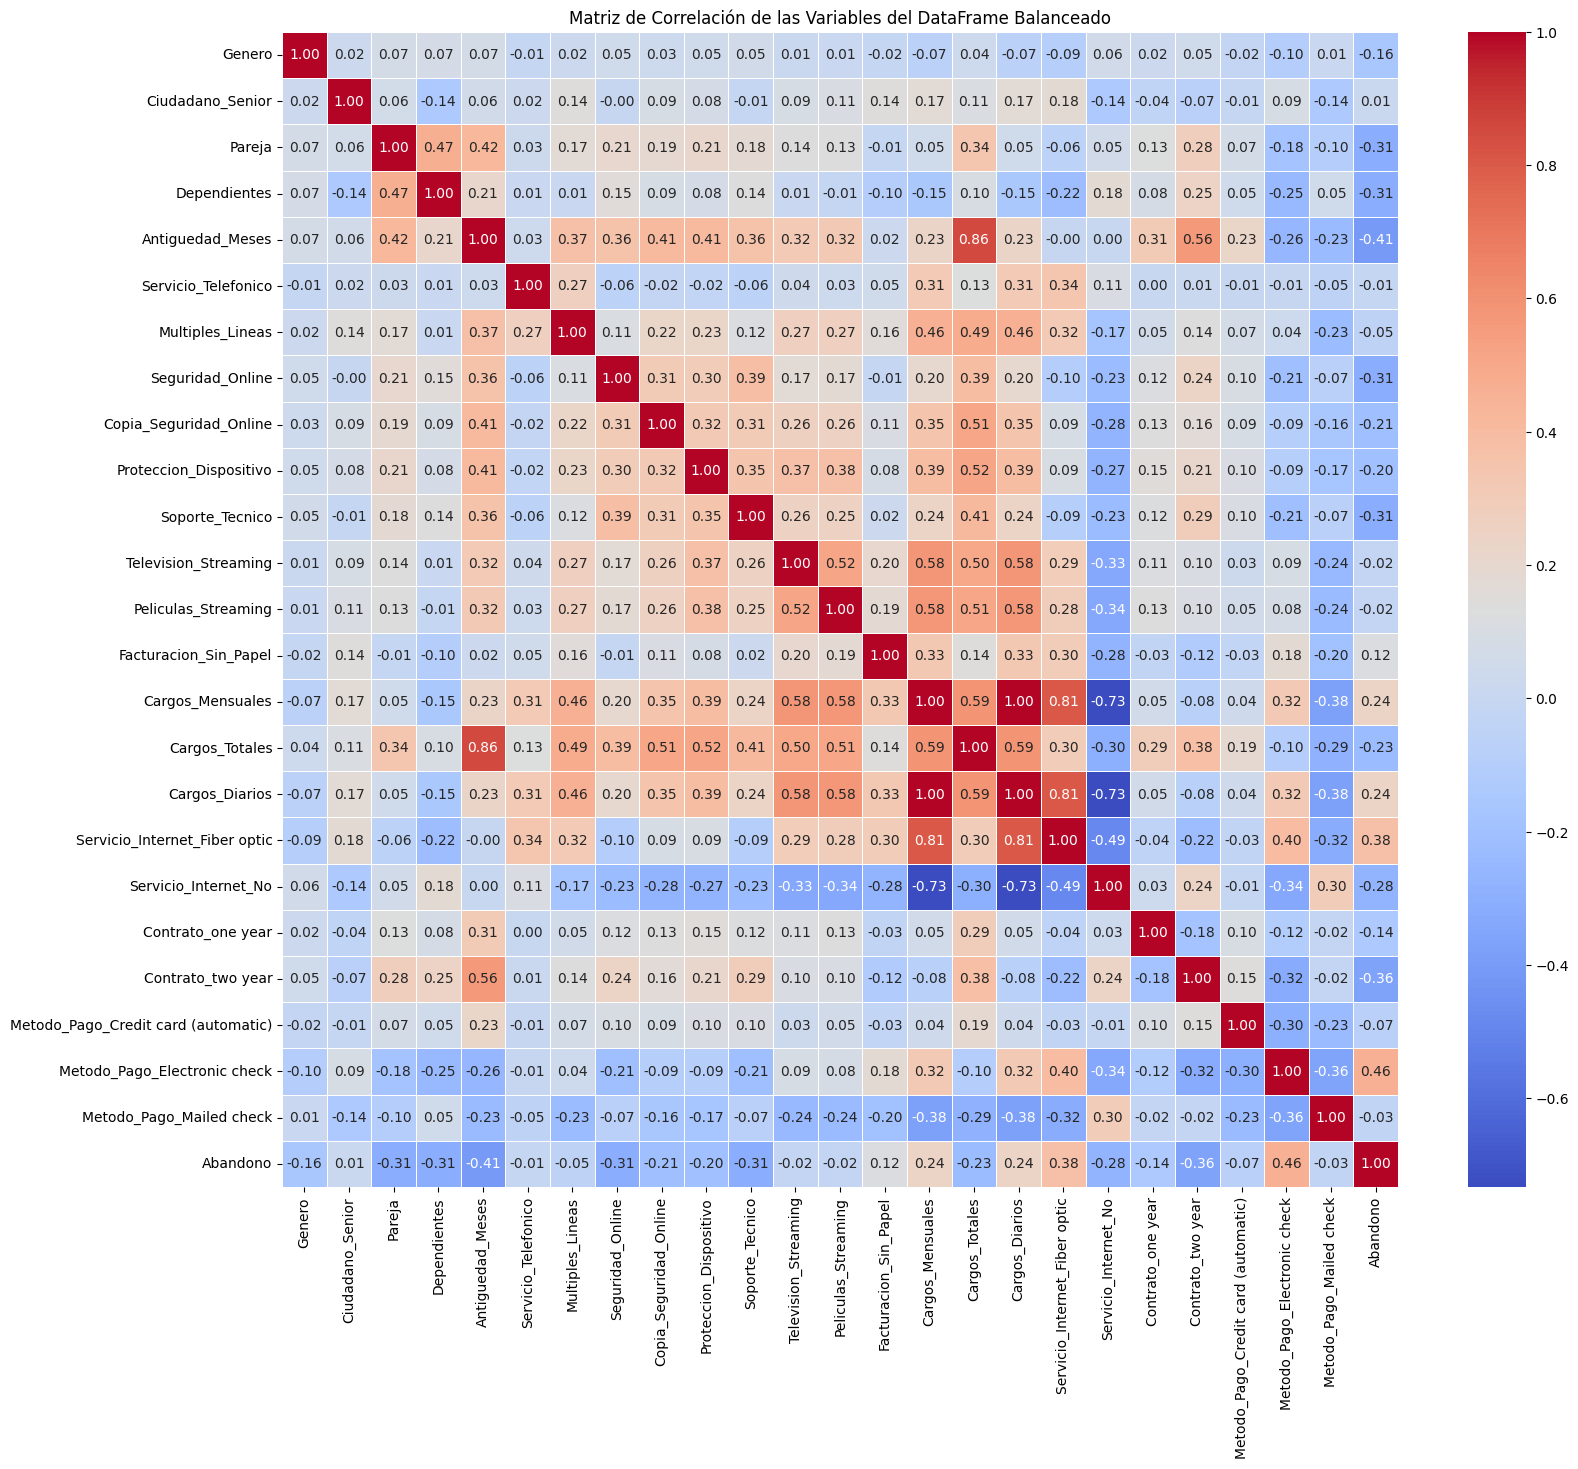

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix = df_balanced.corr(numeric_only=True)


churn_correlations = correlation_matrix['Abandono'].sort_values(ascending=False)

print("Correlación con la variable 'Abandono' (orden descendente):")
print(churn_correlations)

# Para visualizar la matriz de correlación como un mapa de calor
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de las Variables del DataFrame Balanceado')
plt.show()

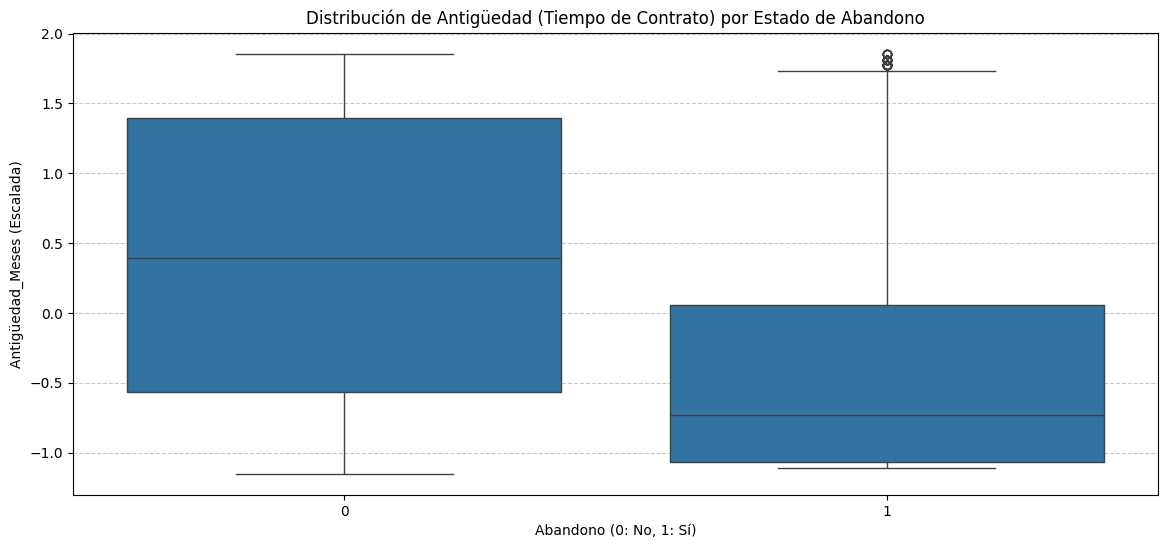

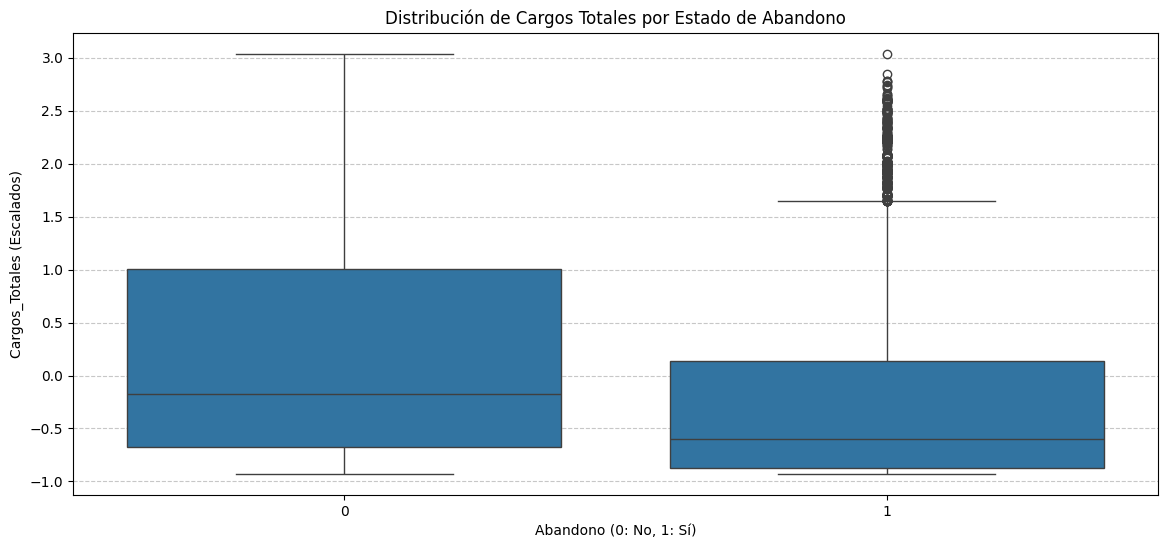

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.boxplot(x='Abandono', y='Antiguedad_Meses', data=df_balanced)
plt.title('Distribución de Antigüedad (Tiempo de Contrato) por Estado de Abandono')
plt.xlabel('Abandono (0: No, 1: Sí)')
plt.ylabel('Antigüedad_Meses (Escalada)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(x='Abandono', y='Cargos_Totales', data=df_balanced)
plt.title('Distribución de Cargos Totales por Estado de Abandono')
plt.xlabel('Abandono (0: No, 1: Sí)')
plt.ylabel('Cargos_Totales (Escalados)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()